In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = "675-50"
obs_mode = "IPOL"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
# print("Interleaved Values")
# print("Length: ", len(interleaved_values))
# print(interleaved_values)
# print("Interleaved Stds")
# print("Length: ", len(interleaved_stds))
# print(interleaved_stds[0 : 10])
# print("Configuration List")
# print("Length: ", len(configuration_list))
# print(configuration_list)
# print(interleaved_stds[0])

# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [3]:
# Loading in previous fit from vampires_calibration
past_fit = np.load("/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/scipy_minimize_20230914_675nm_restrictive_HWP_and_IMR.npy")
print("Past Fit: ", past_fit)

print(past_fit)

theta_pol = past_fit[0]
delta_HWP = past_fit[1]
offset_HWP = past_fit[2]
delta_derot = past_fit[3]
# Keep the starting value inside the +/- 1 degree IMR-offset bounds.
offset_derot = np.clip(past_fit[4], -1, 1)
delta_opts = past_fit[5]
epsilon_opts = past_fit[6]
rot_opts = past_fit[7]
delta_FLC = past_fit[8]
rot_FLC = past_fit[9]
em_gain = 1.181572936405414  # calculated in em_gain_calculations/20230919_calculate_em_gain_ratios.ipynb

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.64  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary


system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {'phi': 0, 'epsilon': 0, 'theta': 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 2 * np.pi * delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {'phi': 2 * np.pi * delta_opts, 'epsilon': epsilon_opts, 'theta': rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 2 * np.pi * delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 2 * np.pi * delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

print(system_dict)

Past Fit:  [ 1.53307627  0.46163077 -2.3687464   0.32815156 -4.99600063 -0.20433489
  0.02210595 18.49730849  0.52007057  4.99645591  1.19152714]
[ 1.53307627  0.46163077 -2.3687464   0.32815156 -4.99600063 -0.20433489
  0.02210595 18.49730849  0.52007057  4.99645591  1.19152714]
{'components': {'wollaston': {'type': 'wollaston_prism_function', 'properties': {'beam': 'o', 'transmission_ratio': 1.181572936405414}}, 'dichroic': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'flc': {'type': 'general_retarder_function', 'properties': {'phi': 3.267699783335079, 'theta': 0, 'delta_theta': 4.996455912303434}}, 'optics': {'type': 'diattenuator_retarder_function', 'properties': {'phi': -1.28387395363109, 'epsilon': 0.022105949364102033, 'theta': 18.49730849075085}}, 'image_rotator': {'type': 'general_retarder_function', 'properties': {'phi': 2.0618370726100776, 'theta': 0, 'delta_theta': 0}}, 'hwp': {'type': 'general_retarder_function', 'properti

In [4]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.56641172 0.56560087 0.03029675 0.        ]
 [0.56641172 0.56560087 0.03029675 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

logl value: 3062.038301772654


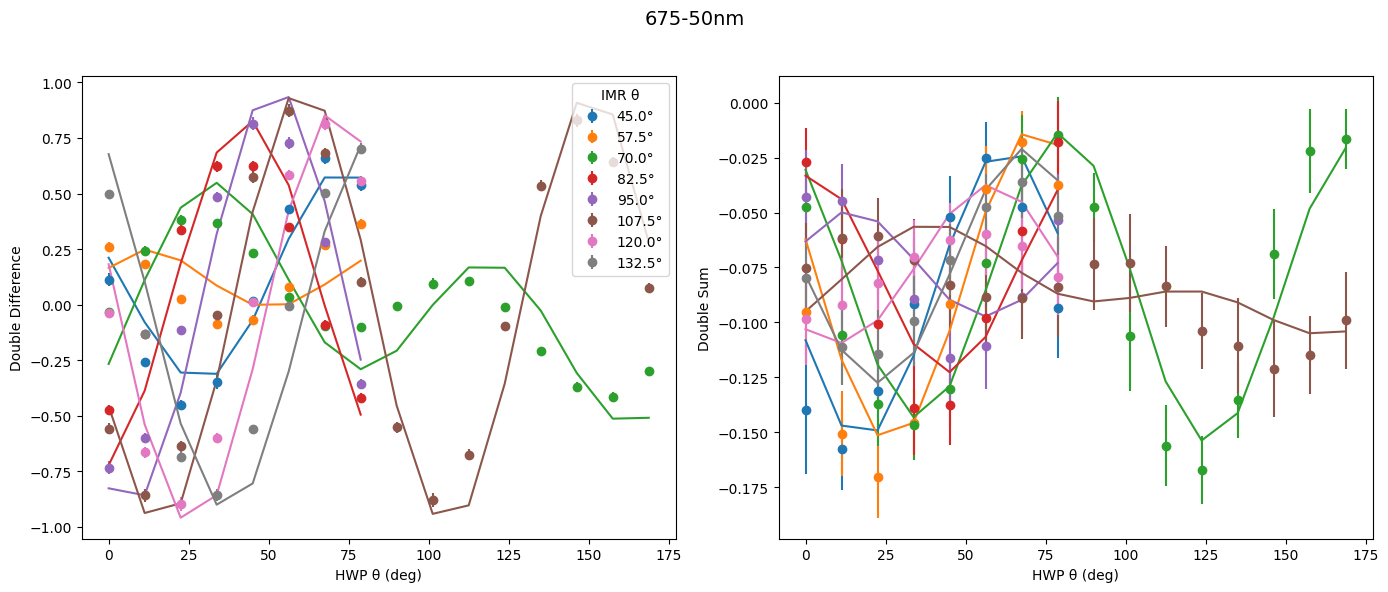

In [5]:
# Fitting all non-EM-gain parameters

p0 = {
    "dichroic": {"phi": 0, 
                 "epsilon": 0, 
                 "theta": 0},
    "flc": {"phi": 2 * np.pi * delta_FLC, "delta_theta": rot_FLC},
    "optics": {"phi": 2 * np.pi * delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
    "image_rotator": {
                    "phi": 2 * np.pi * delta_derot
                    },
    "hwp": {"phi": 2 * np.pi * delta_HWP, "delta_theta": offset_HWP},
    "lp": {"theta": theta_pol}
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.267699783335079, 'delta_theta': 4.996455912303434}, 'optics': {'phi': -1.28387395363109, 'epsilon': 0.022105949364102033, 'theta': 18.49730849075085}, 'image_rotator': {'phi': 2.0618370726100776}, 'hwp': {'phi': 2.900511664638528, 'delta_theta': -2.368746399133097}, 'lp': {'theta': 1.5330762659414212}}
Iteration #: 1
logl_value: 299.3375499753578
Best Fit Parameters: [-5.06845617e-04  1.42453914e-03  7.80493889e-03  3.23288994e+00
  5.00000000e+00 -1.69431623e+00  5.74665367e-03  1.92186591e+01
  2.09392069e+00  2.92359710e+00  9.23794065e-01  2.05332717e+00]


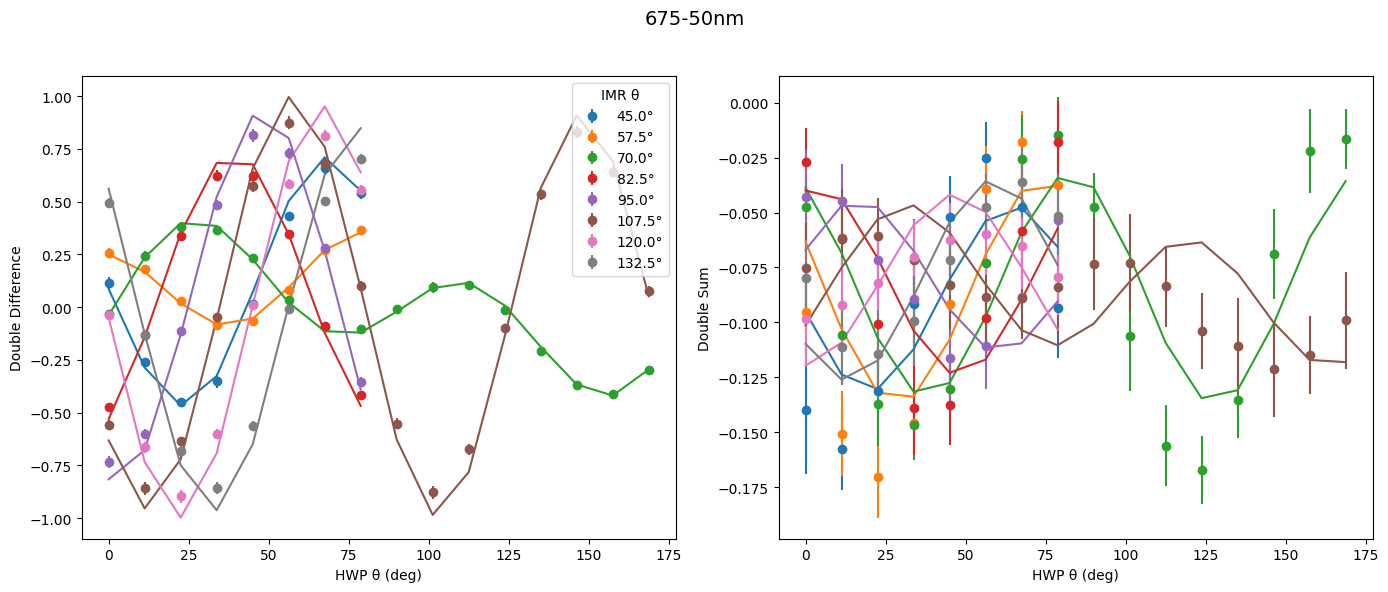

After p0: {'dichroic': {'phi': -0.0005068456173354132, 'epsilon': 0.0014245391430343795, 'theta': 0.0078049388942707165}, 'flc': {'phi': 3.2328899383740985, 'delta_theta': 5.0}, 'optics': {'phi': -1.6943162253636306, 'epsilon': 0.0057466536716535115, 'theta': 19.218659149141516}, 'image_rotator': {'phi': 2.093920692161692}, 'hwp': {'phi': 2.9235970958643707, 'delta_theta': 0.9237940649301408}, 'lp': {'theta': 2.0533271694157356}}
Before p0: {'dichroic': {'phi': -0.0005068456173354132, 'epsilon': 0.0014245391430343795, 'theta': 0.0078049388942707165}, 'flc': {'phi': 3.2328899383740985, 'delta_theta': 5.0}, 'optics': {'phi': -1.6943162253636306, 'epsilon': 0.0057466536716535115, 'theta': 19.218659149141516}, 'image_rotator': {'phi': 2.093920692161692}, 'hwp': {'phi': 2.9235970958643707, 'delta_theta': 0.9237940649301408}, 'lp': {'theta': 2.0533271694157356}}
Iteration #: 2
logl_value: 296.4754083605321
Best Fit Parameters: [-1.19574109e-01  2.71404188e-03 -3.12480139e+00  3.21488952e+00


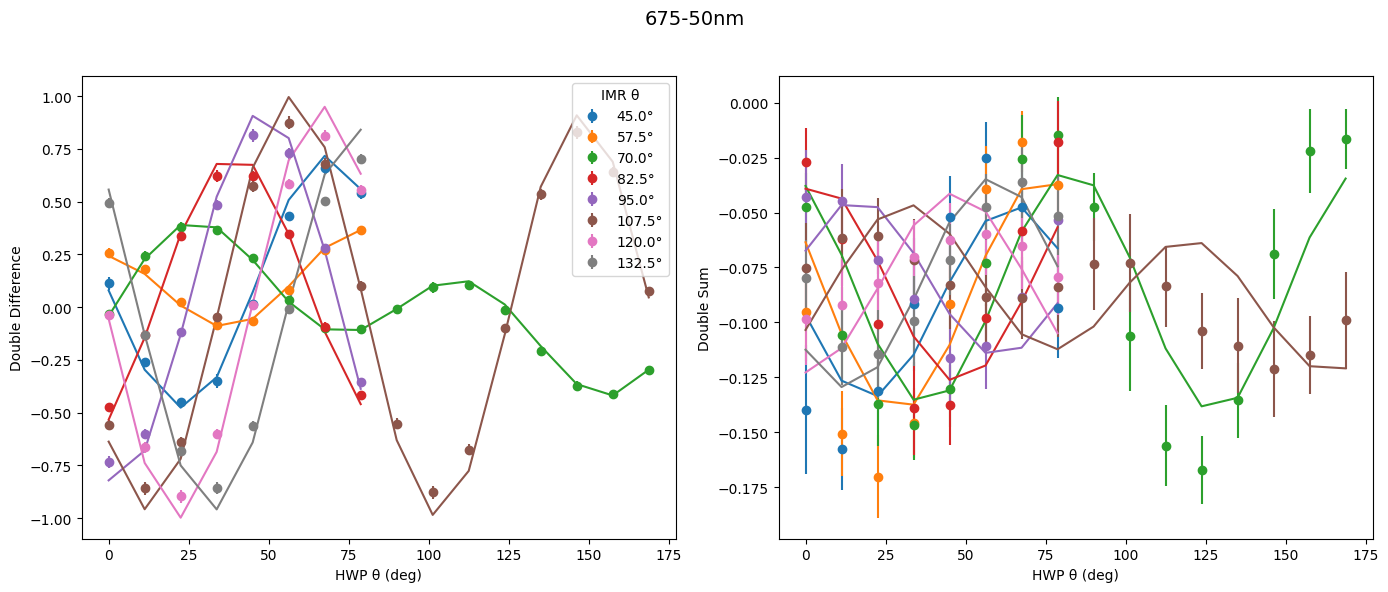

After p0: {'dichroic': {'phi': -0.1195741089560658, 'epsilon': 0.002714041881078739, 'theta': -3.1248013923872904}, 'flc': {'phi': 3.2148895176217795, 'delta_theta': 4.9998385549043824}, 'optics': {'phi': -1.6963765379458096, 'epsilon': 0.002976335566965426, 'theta': 19.101524519489942}, 'image_rotator': {'phi': 2.087177851341613}, 'hwp': {'phi': 2.926277493155185, 'delta_theta': 2.1260307879454645}, 'lp': {'theta': 4.432945039493905}}
Before p0: {'dichroic': {'phi': -0.1195741089560658, 'epsilon': 0.002714041881078739, 'theta': -3.1248013923872904}, 'flc': {'phi': 3.2148895176217795, 'delta_theta': 4.9998385549043824}, 'optics': {'phi': -1.6963765379458096, 'epsilon': 0.002976335566965426, 'theta': 19.101524519489942}, 'image_rotator': {'phi': 2.087177851341613}, 'hwp': {'phi': 2.926277493155185, 'delta_theta': 2.1260307879454645}, 'lp': {'theta': 4.432945039493905}}
Iteration #: 3
logl_value: 203.4559967081925
Best Fit Parameters: [-1.33726584e+00  8.28939478e-03 -1.10842694e+01  2.6

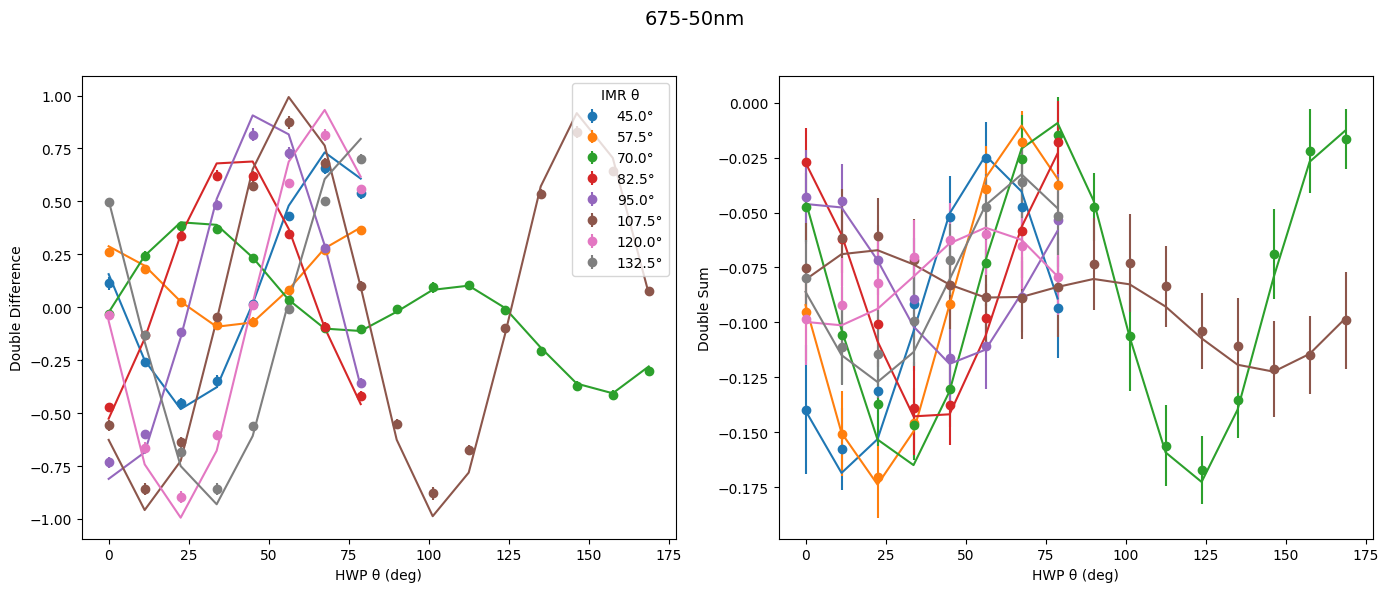

After p0: {'dichroic': {'phi': -1.3372658365768109, 'epsilon': 0.00828939477931856, 'theta': -11.084269440153193}, 'flc': {'phi': 2.67181007382825, 'delta_theta': 4.999081190621402}, 'optics': {'phi': -0.19392380157971945, 'epsilon': 0.0, 'theta': 43.948498772369604}, 'image_rotator': {'phi': 2.014085592952558}, 'hwp': {'phi': 2.917623123927017, 'delta_theta': -2.2491335774596353}, 'lp': {'theta': -2.0296252824546688}}
Before p0: {'dichroic': {'phi': -1.3372658365768109, 'epsilon': 0.00828939477931856, 'theta': -11.084269440153193}, 'flc': {'phi': 2.67181007382825, 'delta_theta': 4.999081190621402}, 'optics': {'phi': -0.19392380157971945, 'epsilon': 0.0, 'theta': 43.948498772369604}, 'image_rotator': {'phi': 2.014085592952558}, 'hwp': {'phi': 2.917623123927017, 'delta_theta': -2.2491335774596353}, 'lp': {'theta': -2.0296252824546688}}
Iteration #: 4
logl_value: 201.08071342631243
Best Fit Parameters: [-1.34965845e+00  5.31477245e-03 -9.98016127e+00  2.73274396e+00
  4.94812721e+00 -3.5

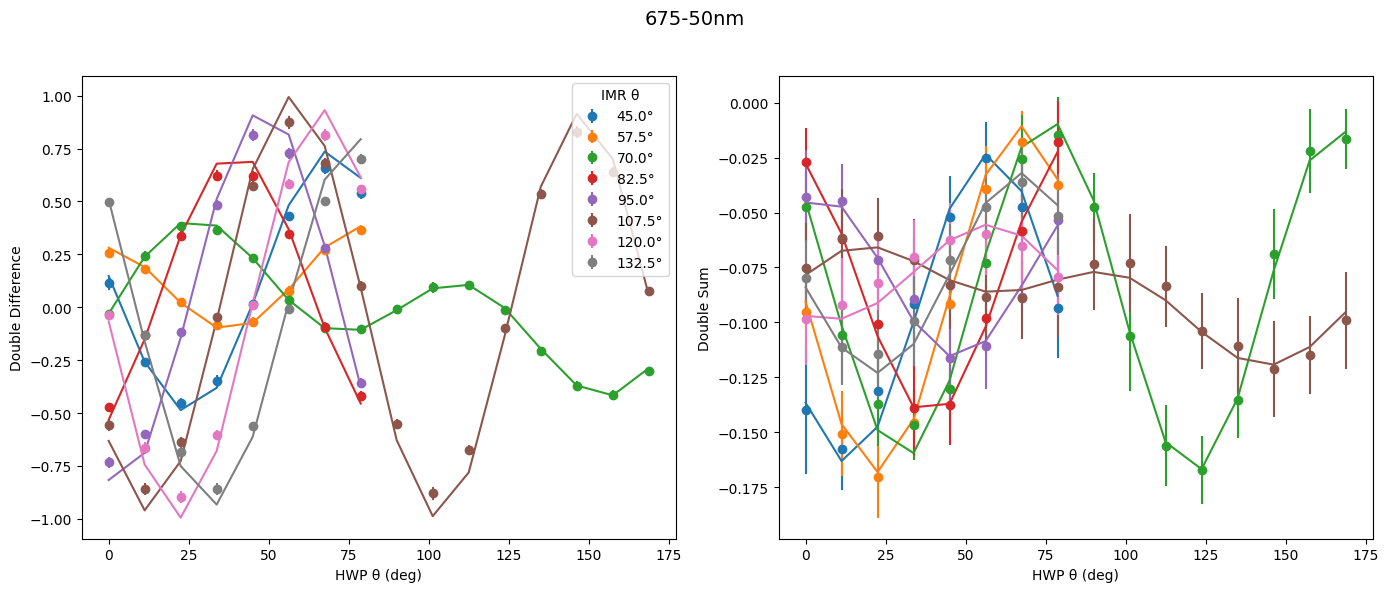

After p0: {'dichroic': {'phi': -1.3496584470521102, 'epsilon': 0.005314772445620206, 'theta': -9.980161271711406}, 'flc': {'phi': 2.732743957520018, 'delta_theta': 4.948127208146964}, 'optics': {'phi': -0.3574585516072898, 'epsilon': 0.002220622845598533, 'theta': 31.712271839611496}, 'image_rotator': {'phi': 2.019280758636505}, 'hwp': {'phi': 2.9157280684199645, 'delta_theta': -1.2494851307962214}, 'lp': {'theta': -0.13077045349182218}}
Before p0: {'dichroic': {'phi': -1.3496584470521102, 'epsilon': 0.005314772445620206, 'theta': -9.980161271711406}, 'flc': {'phi': 2.732743957520018, 'delta_theta': 4.948127208146964}, 'optics': {'phi': -0.3574585516072898, 'epsilon': 0.002220622845598533, 'theta': 31.712271839611496}, 'image_rotator': {'phi': 2.019280758636505}, 'hwp': {'phi': 2.9157280684199645, 'delta_theta': -1.2494851307962214}, 'lp': {'theta': -0.13077045349182218}}
Iteration #: 5
logl_value: 200.85791123997
Best Fit Parameters: [-1.36052454e+00  5.27223605e-03 -8.09503703e+00  2

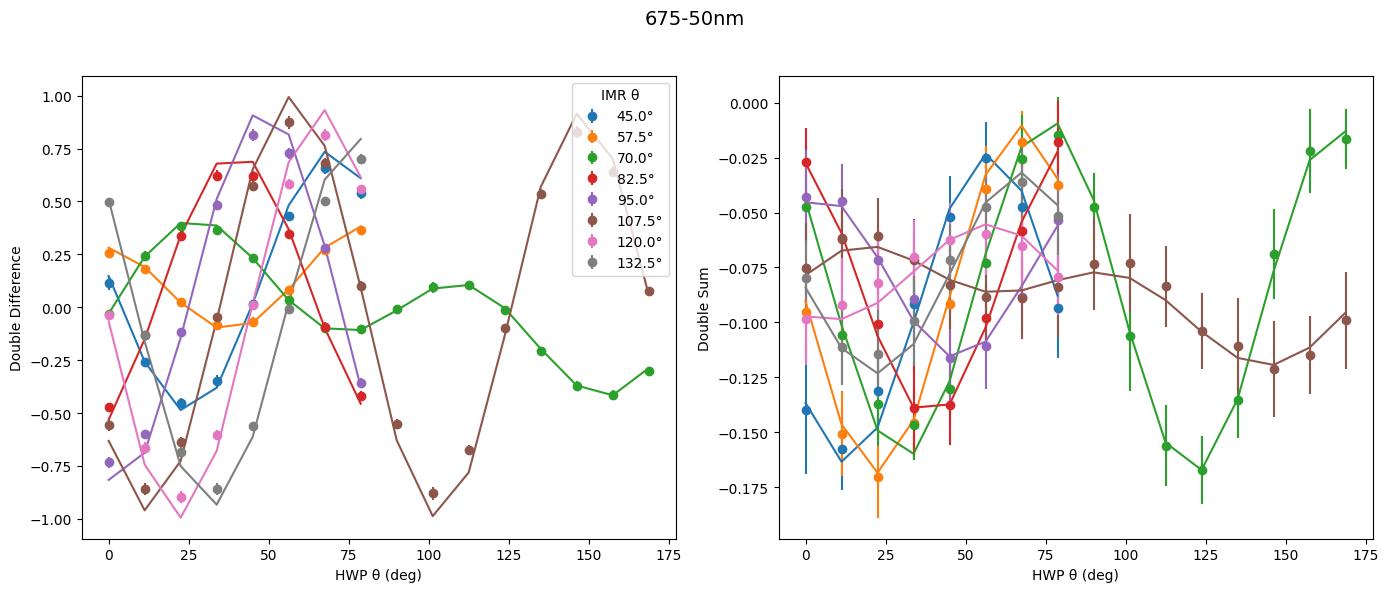

After p0: {'dichroic': {'phi': -1.3605245369892698, 'epsilon': 0.005272236050897839, 'theta': -8.095037030445763}, 'flc': {'phi': 2.8376919122464033, 'delta_theta': 4.999894344143396}, 'optics': {'phi': -0.6615124782673267, 'epsilon': 0.002292960911445944, 'theta': 25.462615664715468}, 'image_rotator': {'phi': 2.0199141598074224}, 'hwp': {'phi': 2.9157622813593678, 'delta_theta': -1.3382610072735495}, 'lp': {'theta': -0.3198135349531165}}
Before p0: {'dichroic': {'phi': -1.3605245369892698, 'epsilon': 0.005272236050897839, 'theta': -8.095037030445763}, 'flc': {'phi': 2.8376919122464033, 'delta_theta': 4.999894344143396}, 'optics': {'phi': -0.6615124782673267, 'epsilon': 0.002292960911445944, 'theta': 25.462615664715468}, 'image_rotator': {'phi': 2.0199141598074224}, 'hwp': {'phi': 2.9157622813593678, 'delta_theta': -1.3382610072735495}, 'lp': {'theta': -0.3198135349531165}}
Iteration #: 6
logl_value: 200.83675710181376
Best Fit Parameters: [-1.39408645e+00  5.20904524e-03 -7.44334580e+

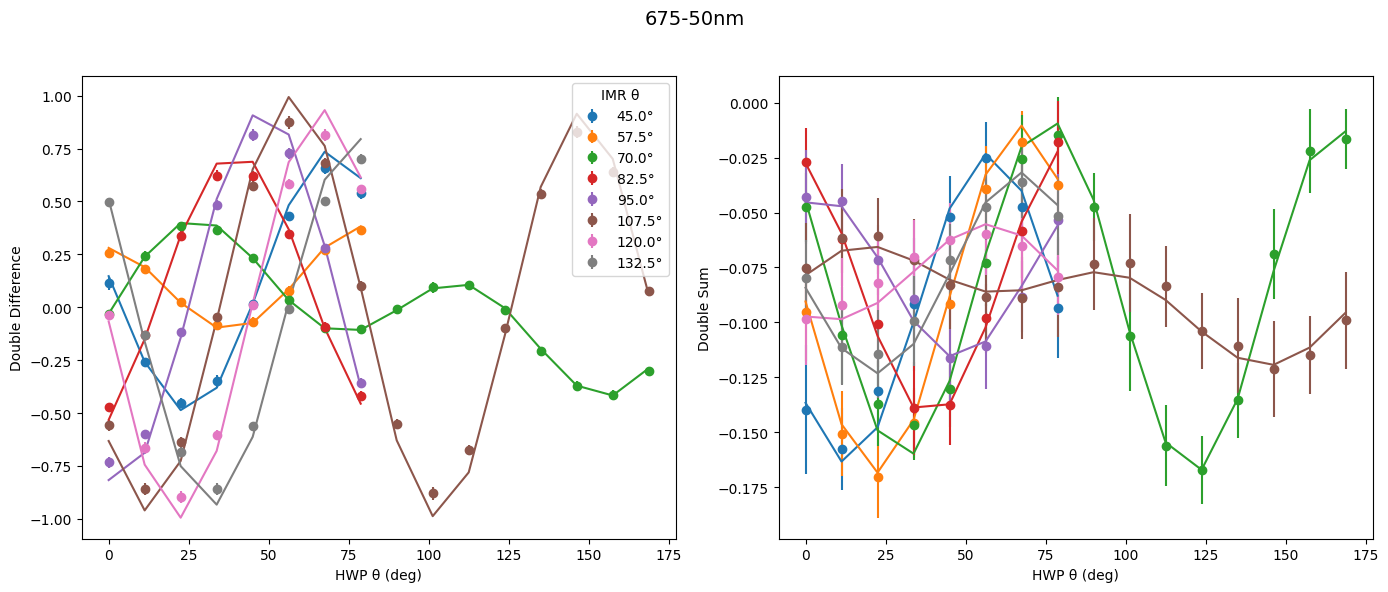

After p0: {'dichroic': {'phi': -1.3940864541170992, 'epsilon': 0.0052090452400889095, 'theta': -7.443345802471835}, 'flc': {'phi': 2.8702182096586037, 'delta_theta': 4.999766673154838}, 'optics': {'phi': -0.7398906551893061, 'epsilon': 0.002321379492484432, 'theta': 24.71395951512926}, 'image_rotator': {'phi': 2.0201663973708044}, 'hwp': {'phi': 2.9156671467087842, 'delta_theta': -1.2273886840562729}, 'lp': {'theta': -0.10999737677890581}}
Before p0: {'dichroic': {'phi': -1.3940864541170992, 'epsilon': 0.0052090452400889095, 'theta': -7.443345802471835}, 'flc': {'phi': 2.8702182096586037, 'delta_theta': 4.999766673154838}, 'optics': {'phi': -0.7398906551893061, 'epsilon': 0.002321379492484432, 'theta': 24.71395951512926}, 'image_rotator': {'phi': 2.0201663973708044}, 'hwp': {'phi': 2.9156671467087842, 'delta_theta': -1.2273886840562729}, 'lp': {'theta': -0.10999737677890581}}
Iteration #: 7
logl_value: 200.83675300913163
Best Fit Parameters: [-1.39386705e+00  5.20896958e-03 -7.44558848

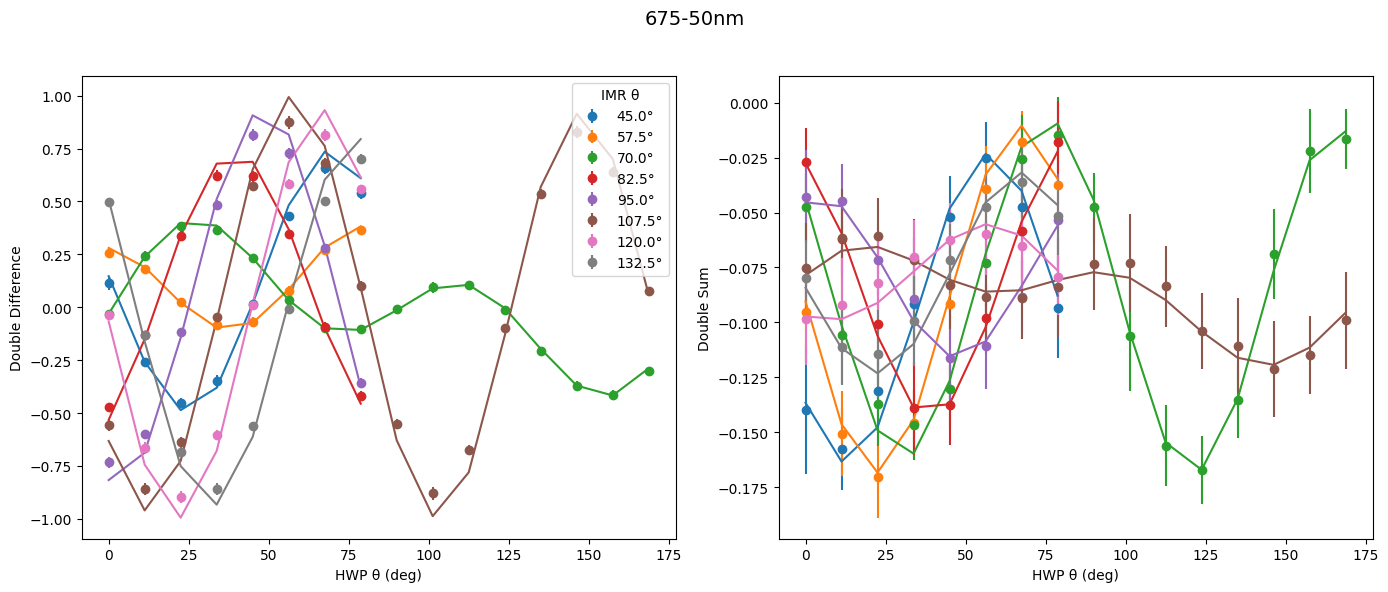

After p0: {'dichroic': {'phi': -1.3938670544784144, 'epsilon': 0.005208969577597047, 'theta': -7.445588476703527}, 'flc': {'phi': 2.87011043913978, 'delta_theta': 4.99999959964345}, 'optics': {'phi': -0.7396361171962114, 'epsilon': 0.002321060593303493, 'theta': 24.716109994633328}, 'image_rotator': {'phi': 2.020170870651231}, 'hwp': {'phi': 2.91566691807055, 'delta_theta': -1.227159626983772}, 'lp': {'theta': -0.10965851119666148}}
Before p0: {'dichroic': {'phi': -1.3938670544784144, 'epsilon': 0.005208969577597047, 'theta': -7.445588476703527}, 'flc': {'phi': 2.87011043913978, 'delta_theta': 4.99999959964345}, 'optics': {'phi': -0.7396361171962114, 'epsilon': 0.002321060593303493, 'theta': 24.716109994633328}, 'image_rotator': {'phi': 2.020170870651231}, 'hwp': {'phi': 2.91566691807055, 'delta_theta': -1.227159626983772}, 'lp': {'theta': -0.10965851119666148}}
Iteration #: 8
logl_value: 200.83675293880603
Best Fit Parameters: [-1.39386809e+00  5.20914369e-03 -7.44557469e+00  2.870110

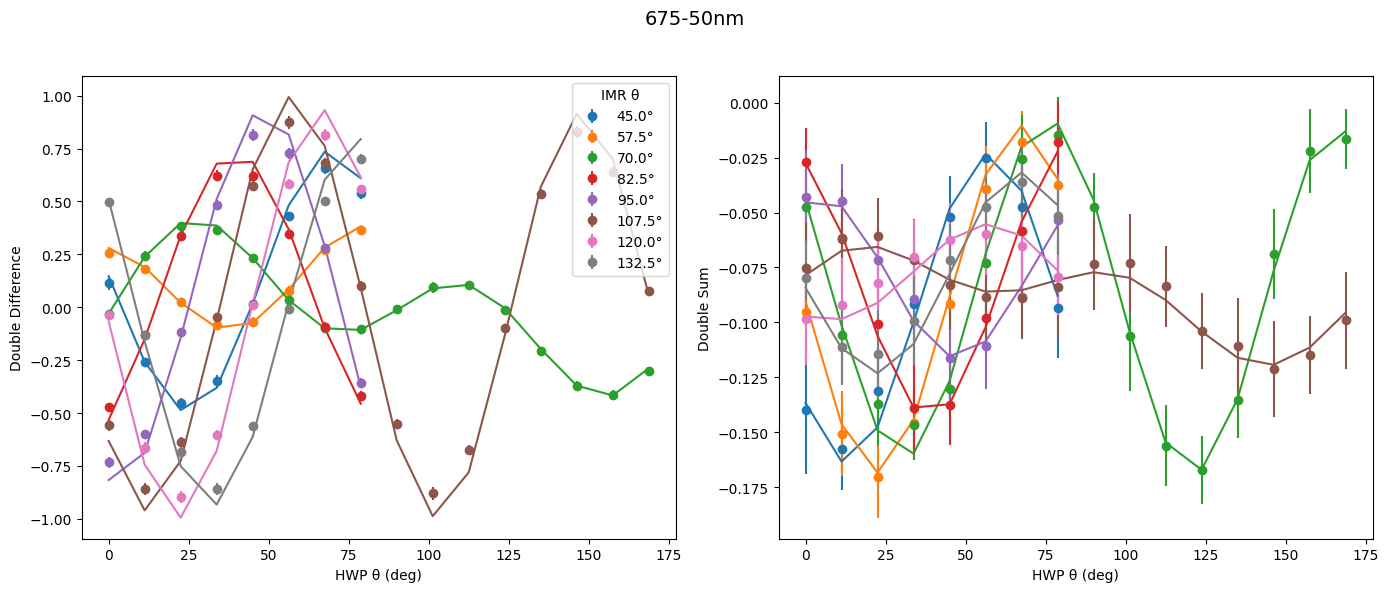

After p0: {'dichroic': {'phi': -1.393868091770003, 'epsilon': 0.005209143685672367, 'theta': -7.445574694979571}, 'flc': {'phi': 2.8701109006418246, 'delta_theta': 4.999999218197834}, 'optics': {'phi': -0.7396439069100663, 'epsilon': 0.0023210354945930297, 'theta': 24.71597539871331}, 'image_rotator': {'phi': 2.020168431833281}, 'hwp': {'phi': 2.9156667704158066, 'delta_theta': -1.2271597677919026}, 'lp': {'theta': -0.10960910659112225}}
Before p0: {'dichroic': {'phi': -1.393868091770003, 'epsilon': 0.005209143685672367, 'theta': -7.445574694979571}, 'flc': {'phi': 2.8701109006418246, 'delta_theta': 4.999999218197834}, 'optics': {'phi': -0.7396439069100663, 'epsilon': 0.0023210354945930297, 'theta': 24.71597539871331}, 'image_rotator': {'phi': 2.020168431833281}, 'hwp': {'phi': 2.9156667704158066, 'delta_theta': -1.2271597677919026}, 'lp': {'theta': -0.10960910659112225}}
Iteration #: 9
logl_value: 200.836752920477
Best Fit Parameters: [-1.39387116e+00  5.20923875e-03 -7.44560532e+00  

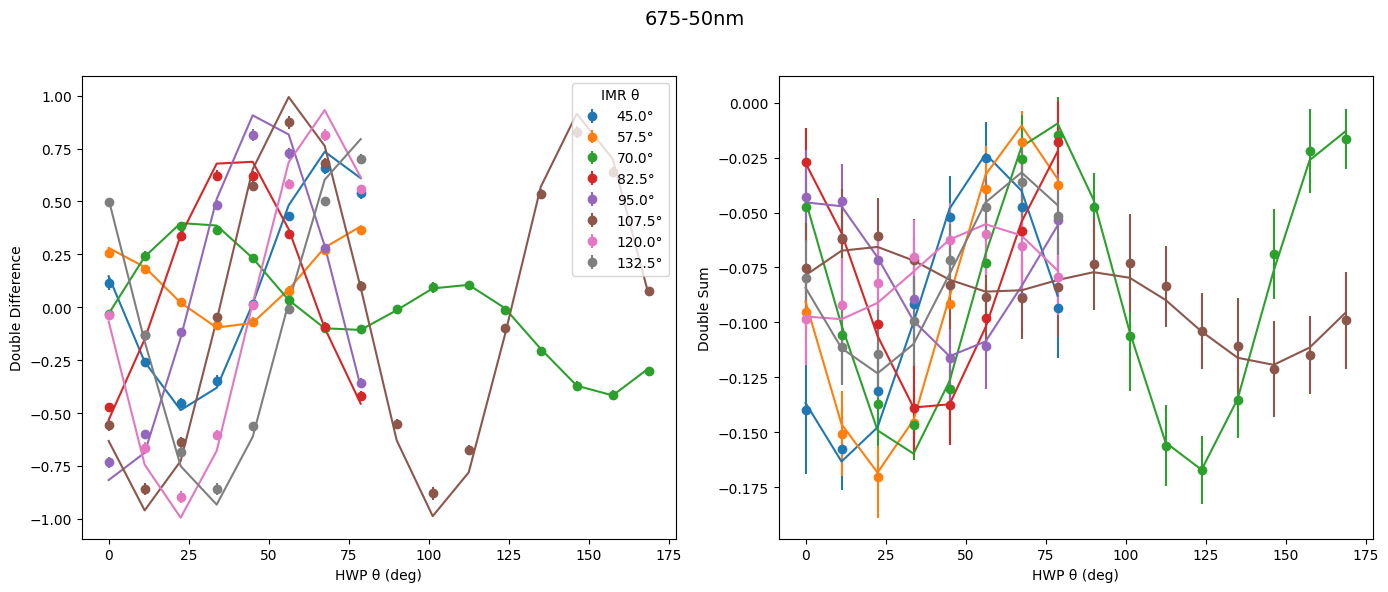

After p0: {'dichroic': {'phi': -1.3938711574213065, 'epsilon': 0.005209238748378545, 'theta': -7.445605323627496}, 'flc': {'phi': 2.8701090006190295, 'delta_theta': 4.999999119252516}, 'optics': {'phi': -0.7396375911802608, 'epsilon': 0.002321229389085099, 'theta': 24.716019860602074}, 'image_rotator': {'phi': 2.0201674353850407}, 'hwp': {'phi': 2.9156665754145195, 'delta_theta': -1.2272137742157683}, 'lp': {'theta': -0.10967918339926608}}
Before p0: {'dichroic': {'phi': -1.3938711574213065, 'epsilon': 0.005209238748378545, 'theta': -7.445605323627496}, 'flc': {'phi': 2.8701090006190295, 'delta_theta': 4.999999119252516}, 'optics': {'phi': -0.7396375911802608, 'epsilon': 0.002321229389085099, 'theta': 24.716019860602074}, 'image_rotator': {'phi': 2.0201674353850407}, 'hwp': {'phi': 2.9156665754145195, 'delta_theta': -1.2272137742157683}, 'lp': {'theta': -0.10967918339926608}}
Iteration #: 10
logl_value: 200.836752920477
Best Fit Parameters: [-1.39387116e+00  5.20923875e-03 -7.44560532e

In [6]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds = [ 
    (-2 * np.pi, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-90, 90), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # delta_FLC
    (-5, 5),  # rot_FLC
    (-np.pi, np.pi),  # delta_opts
    (0, 0.1),  # epsilon_opts
    (-90, 90),  # rot_opts
    ((delta_derot - delta_derot * 0.1) * 2 * np.pi, (delta_derot + delta_derot * 0.1) * 2 * np.pi),  # delta_derot
    ((delta_HWP - delta_HWP * 0.1) * 2 * np.pi, 0.5 * 2 * np.pi),  # delta_HWP
    (-5, 5),  # offset_HWP
    (-5, 5),  # theta_pol
]
# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

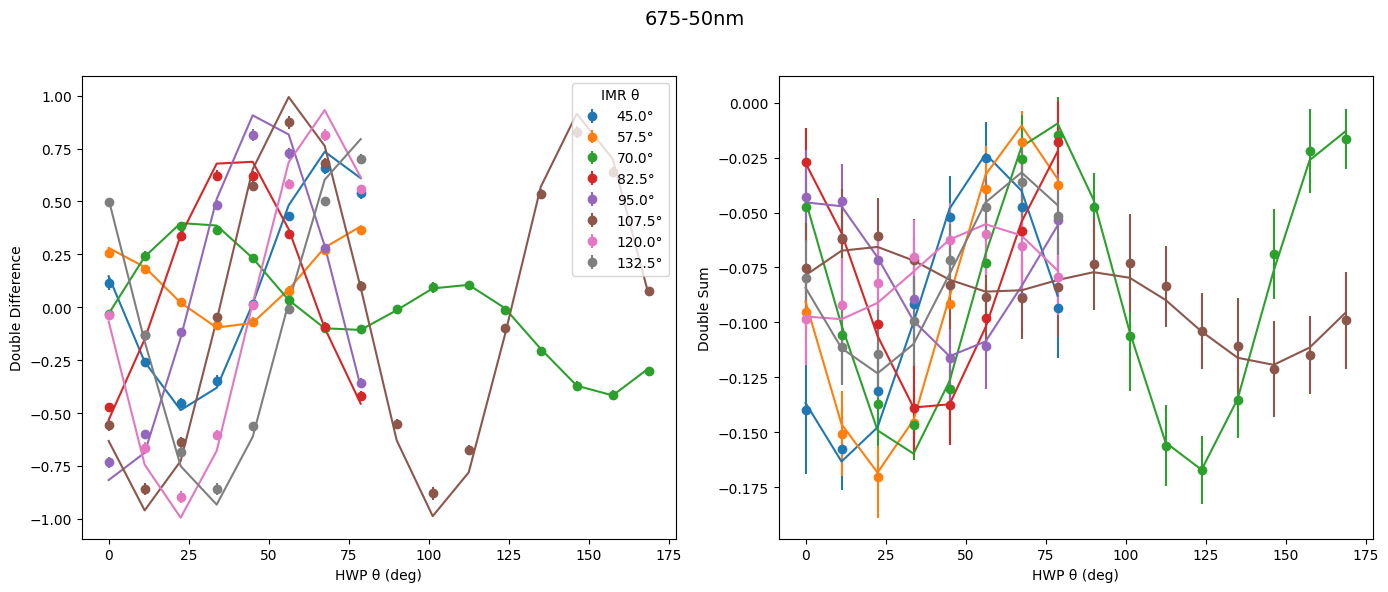

In [7]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)